## Downscale Pressure: Algorithm evaluation and Testing

In [1]:
%matplotlib ipympl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from model_datasets.gamut import GamutDataset 
from buildforcing.datasets import siteNLDAS
from buildforcing.downscale import downscalePressureV0
from datetime import datetime
import os


Using Tony Grove RS for evaluation

In [2]:
# 6332 ft
snotel_elevation = 6332 * 0.3048  # Convert feet to meters

In [3]:
tg_nldas = siteNLDAS('Tony Grove RS', datetime(2015, 10, 1), datetime(2016, 10, 1), os.getenv('NLDAS_PATH'))
tg_nldas.loadNetCDF()
tg_nldas.data.head()

,LWdown,PSurf,Qair,Rainf,SWdown,Tair,Wind_E,Wind_N,elevation
Date&Time,,,,,,,,,
2015-10-01 00:00:00+00:00,304.92,77372.3,0.005122,0.0,144.024,293.81,0.53,2.29,2328.907959
2015-10-01 01:00:00+00:00,304.82,77228.2,0.005087,0.0,12.272,291.98,-0.41,1.94,2328.907959
2015-10-01 02:00:00+00:00,304.73,77083.9,0.005051,0.0,0.000,290.16,-1.35,1.58,2328.907959
2015-10-01 03:00:00+00:00,309.38,76939.5,0.005015,0.0,0.000,288.34,-2.29,1.22,2328.907959
2015-10-01 04:00:00+00:00,309.35,77037.5,0.005007,0.0,0.000,287.94,-2.47,1.49,2328.907959


In [4]:
tg_gamut = GamutDataset('Tony Grove')
gamut_variables = tg_gamut.get_variables()
print(gamut_variables)

['BP_Avg', 'AirTemp_ST110_Avg', 'RH_HC2S3']


In [11]:
tg_gamut_bp = tg_gamut.get_data('BP_Avg')
tg_gamut_bp = tg_gamut_bp['2015-10-01':'2016-10-01']

dtype('O')

### Downscale

In [7]:
tg_nldas_bp_kPa_downscaled = downscalePressureV0(tg_nldas.data['PSurf'], tg_nldas.data['Tair'], snotel_elevation, tg_nldas.elevation)/1000  # Convert Pa to kPa

### Plot

TypeError: no numeric data to plot

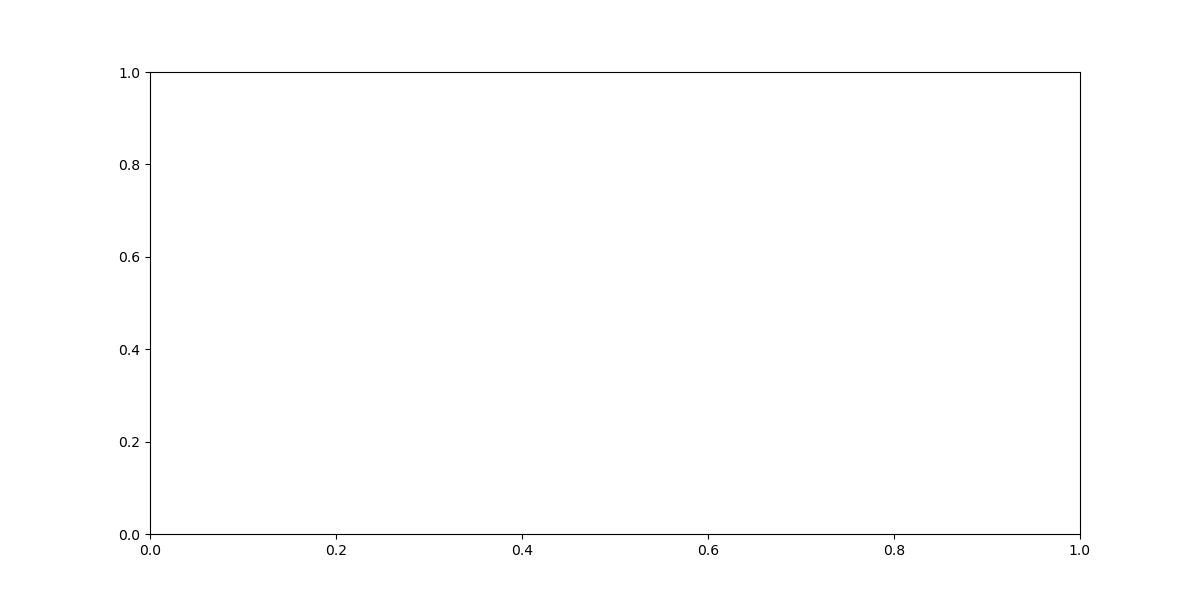

In [12]:
# Compare downscaled to Gamut
plt.figure(figsize=(12, 6))
tg_gamut_bp.plot(label='Gamut BP_Avg', color='blue')
tg_nldas_bp_kPa_downscaled.plot(label='Downscaled NLDAS PSurf', color='orange', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Pressure (kPa)')
plt.title('Comparison of Downscaled NLDAS Pressure to Gamut BP_Avg')
